In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

scheme_performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

investor_transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

portfolio_holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Scheme Performance:", scheme_performance.shape)
print("Investor Transactions:", investor_transactions.shape)
print("Portfolio Holdings:", portfolio_holdings.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)
Portfolio Holdings: (322, 8)


In [ ]:

nav_history["date"] = pd.to_datetime(nav_history["date"])

top_funds = nav_history["amfi_code"].unique()[:5]

nav_sample = nav_history[
    nav_history["amfi_code"].isin(top_funds)
]

fig = px.line(
    nav_sample,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (Sample Funds)"
)

fig.show()

In [4]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.shape)
print(aum.columns.tolist())

aum.head()

(90, 5)
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [5]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


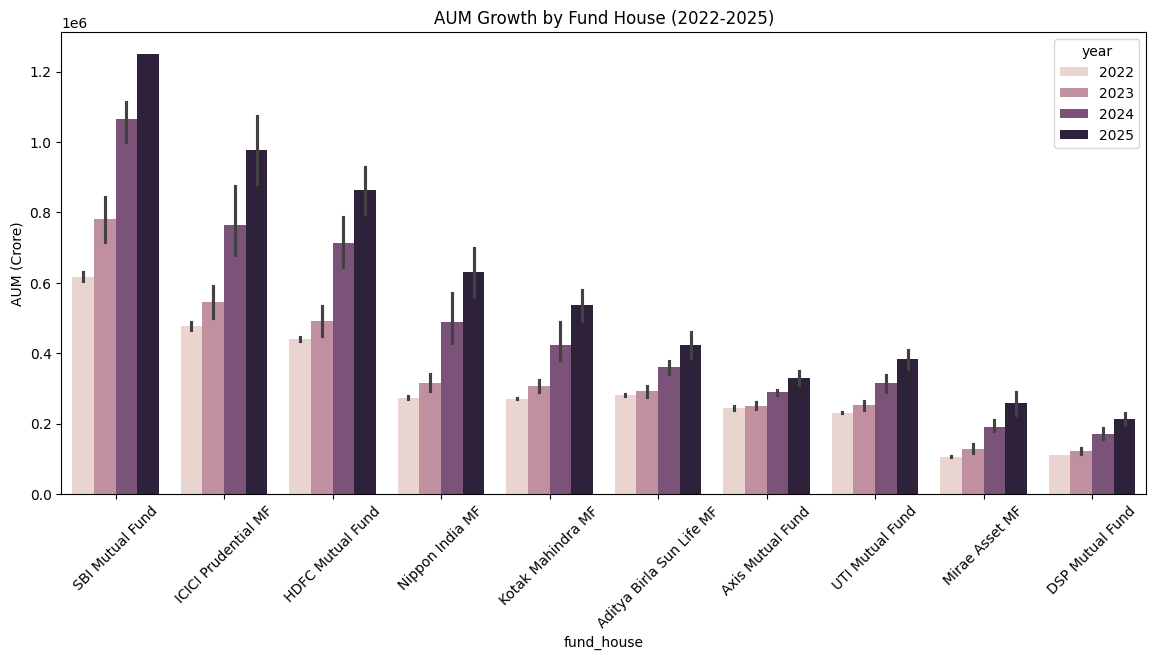

In [6]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.xticks(rotation=45)
plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Crore)")

plt.show()

In [7]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.shape)
print(sip.columns.tolist())

sip.head()

(48, 6)
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


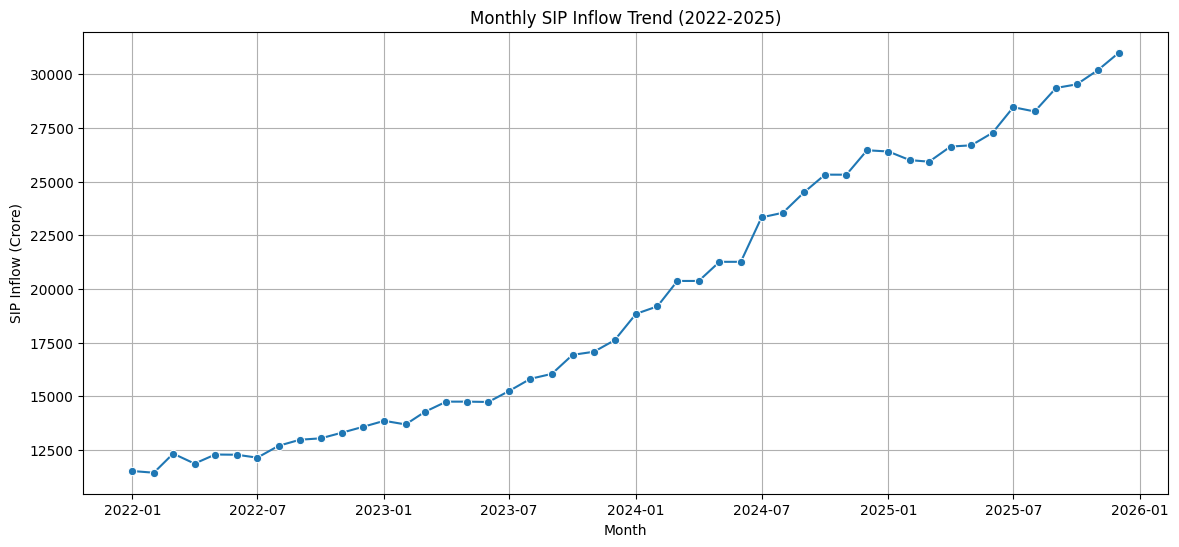

In [ ]:


sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_inflow_crore",
    marker="o"
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.grid(True)

plt.show()

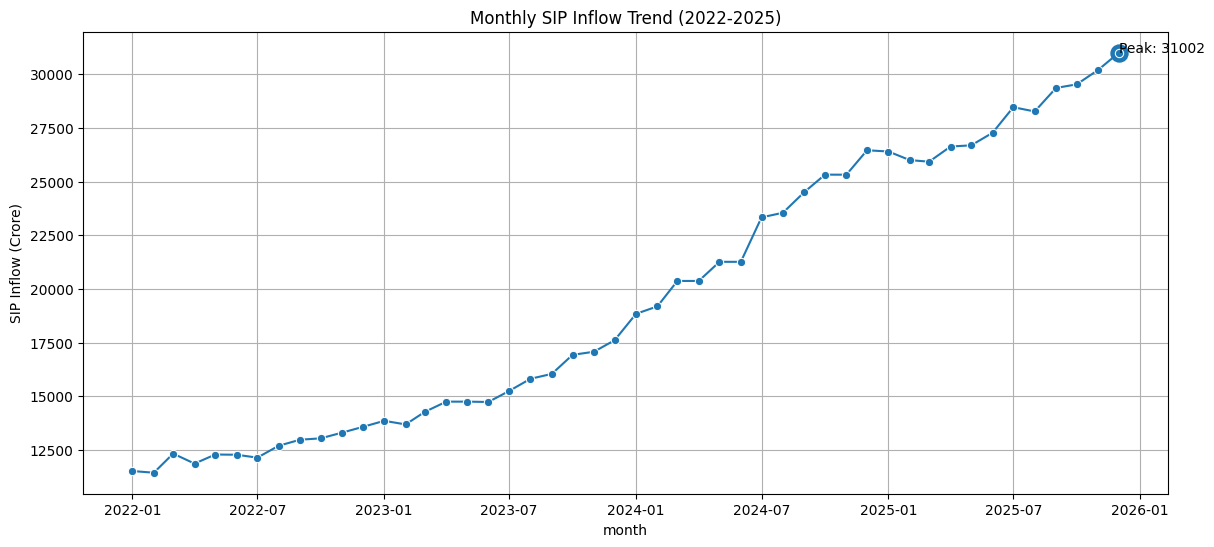

In [ ]:

sip["month"] = pd.to_datetime(sip["month"])

peak_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_inflow_crore",
    marker="o"
)

plt.scatter(
    peak_row["month"],
    peak_row["sip_inflow_crore"],
    s=150
)

plt.annotate(
    f'Peak: {peak_row["sip_inflow_crore"]}',
    (
        peak_row["month"],
        peak_row["sip_inflow_crore"]
    )
)

plt.title("Monthly SIP Inflow Trend (2022-2025)")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)

plt.show()

In [10]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.shape)
print(category.columns.tolist())

category.head()

(144, 3)
['month', 'category', 'net_inflow_crore']


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


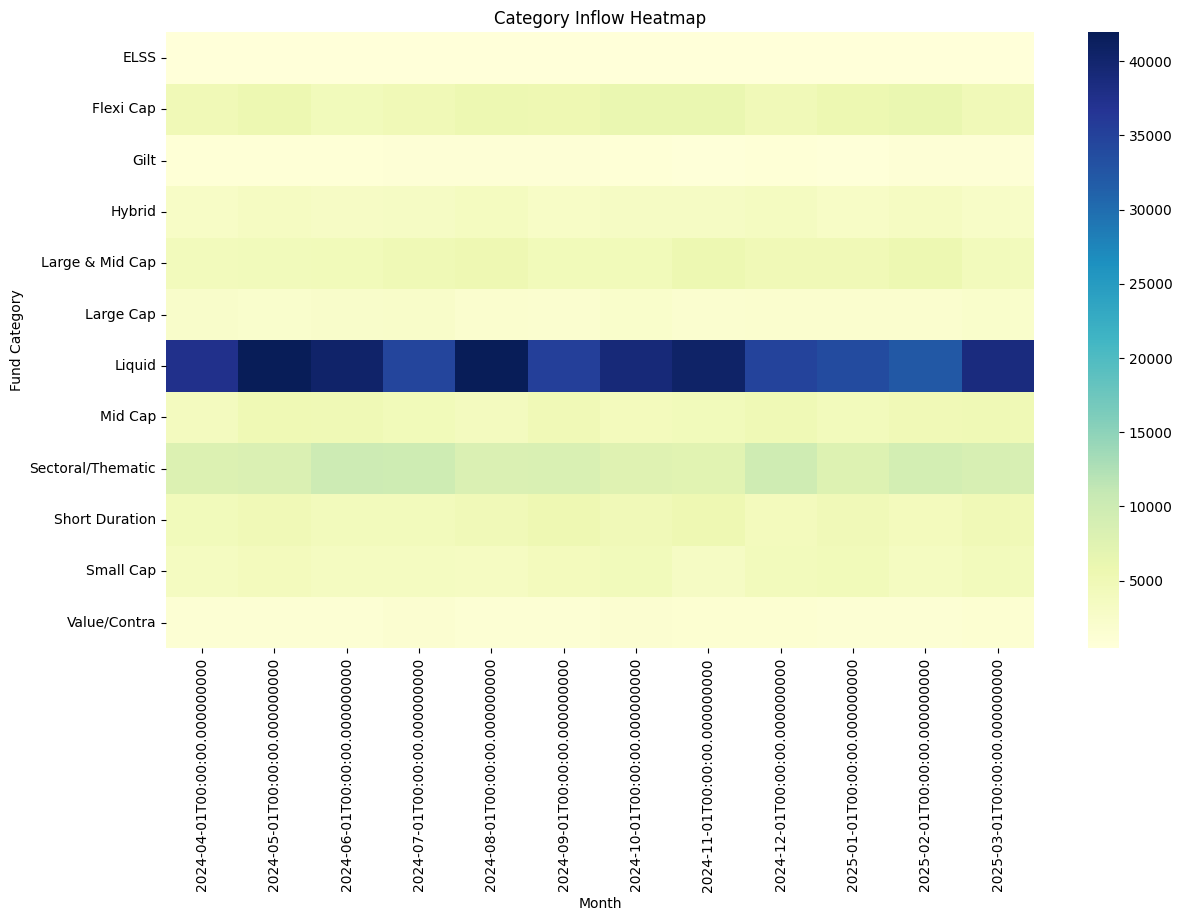

In [ ]:


category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

In [12]:
print(investor_transactions["age_group"].value_counts())

print("\nGender Values:")
print(investor_transactions["gender"].value_counts())

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender Values:
gender
Male      21809
Female    10969
Name: count, dtype: int64


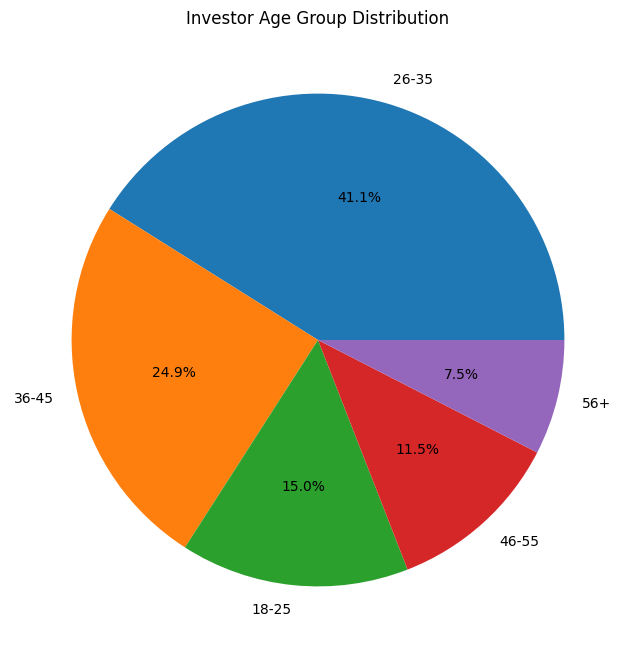

In [13]:
age_counts = investor_transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

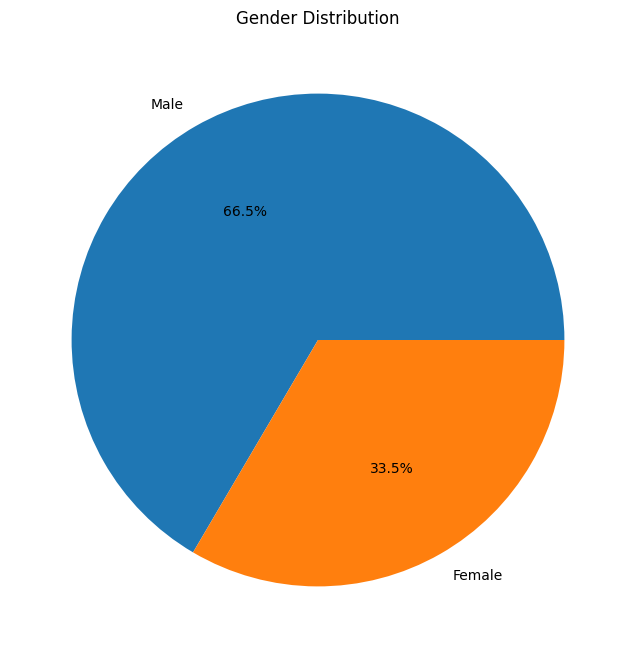

In [14]:
gender_counts = investor_transactions["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

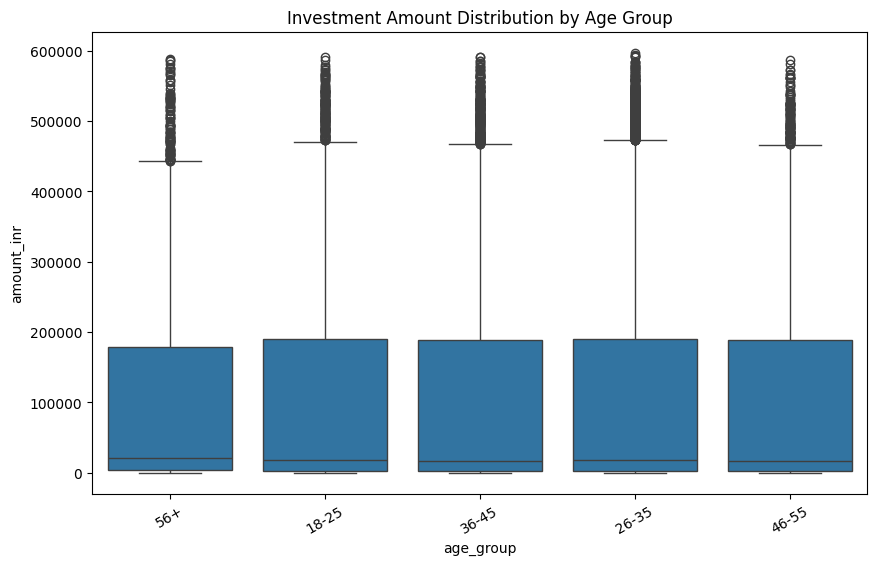

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.xticks(rotation=30)

plt.show()

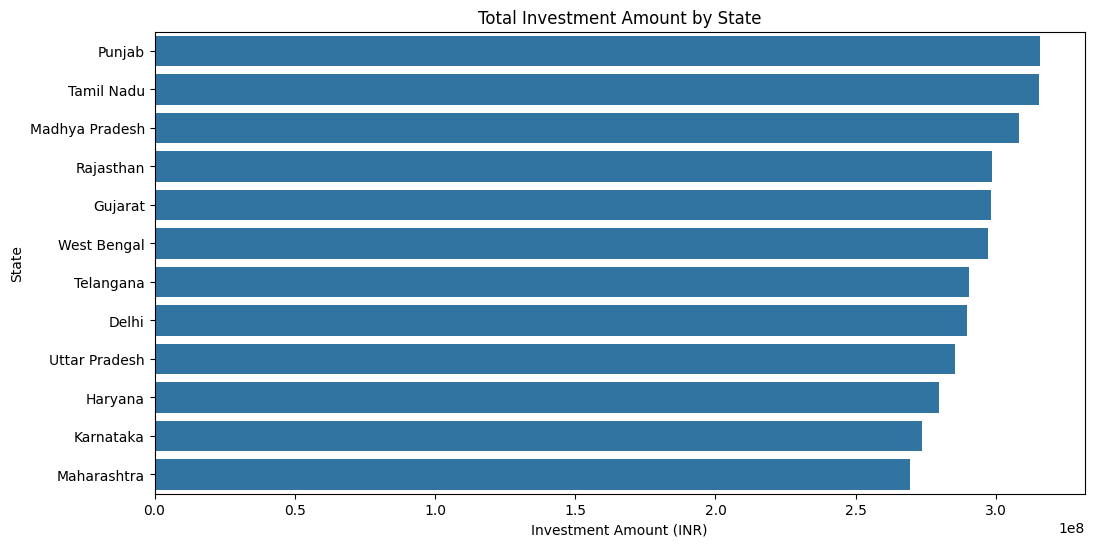

In [16]:
state_amount = investor_transactions.groupby("state")["amount_inr"].sum()

state_amount = state_amount.sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.show()

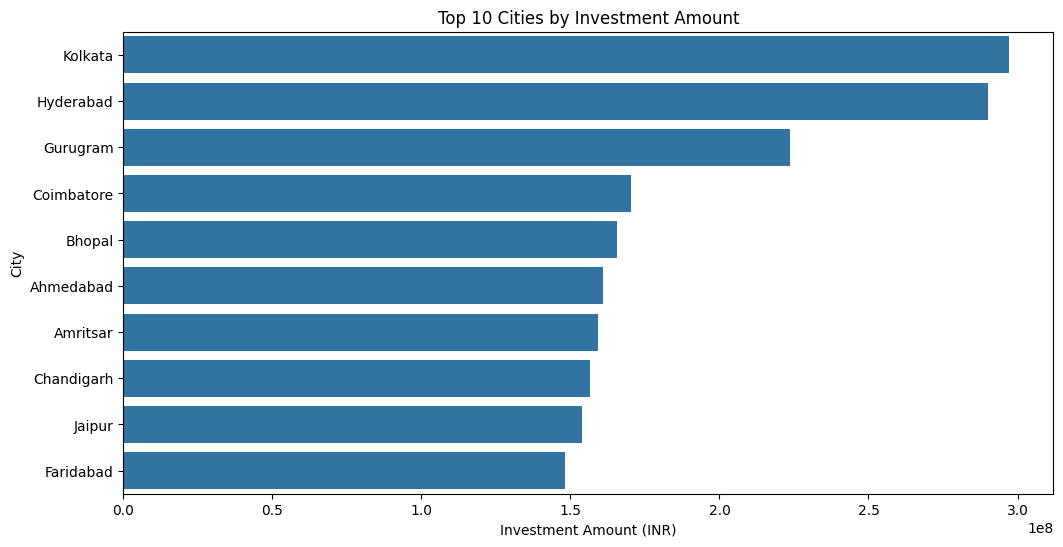

In [17]:
city_amount = investor_transactions.groupby("city")["amount_inr"].sum()

city_amount = city_amount.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=city_amount.values,
    y=city_amount.index
)

plt.title("Top 10 Cities by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("City")

plt.show()

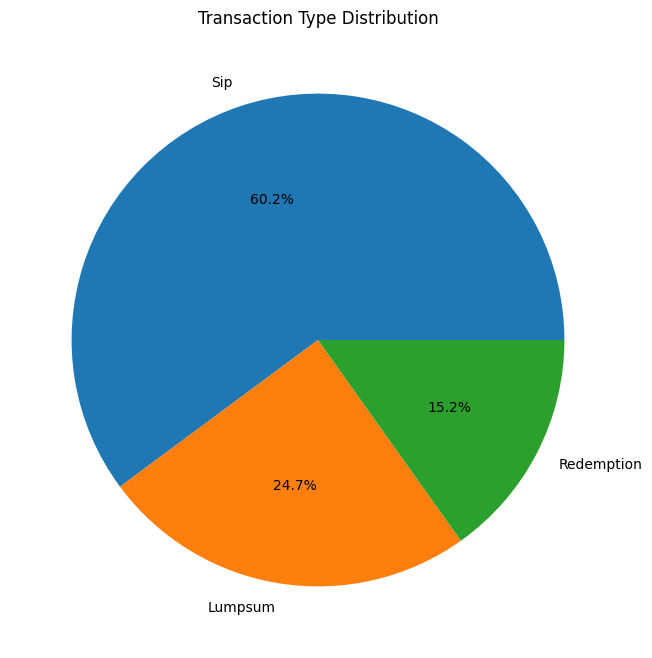

In [18]:
txn_counts = investor_transactions["transaction_type"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    txn_counts,
    labels=txn_counts.index,
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution")

plt.show()

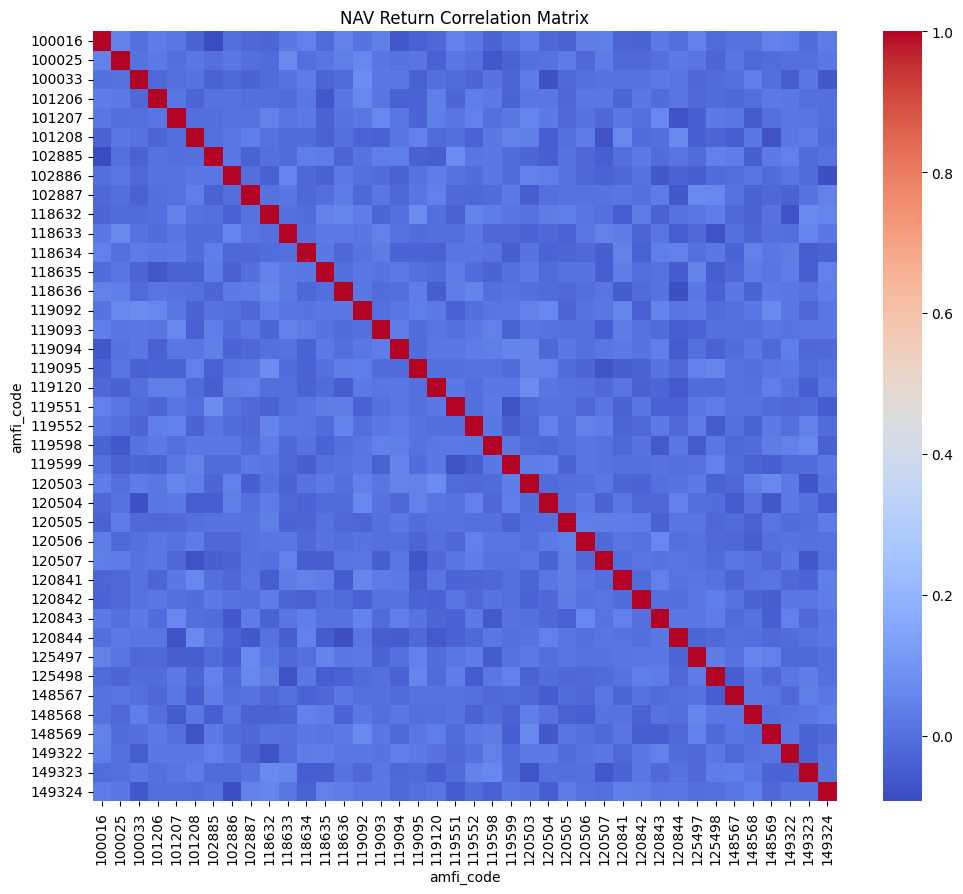

In [ ]:
nav_pivot = nav_history.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_pivot.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

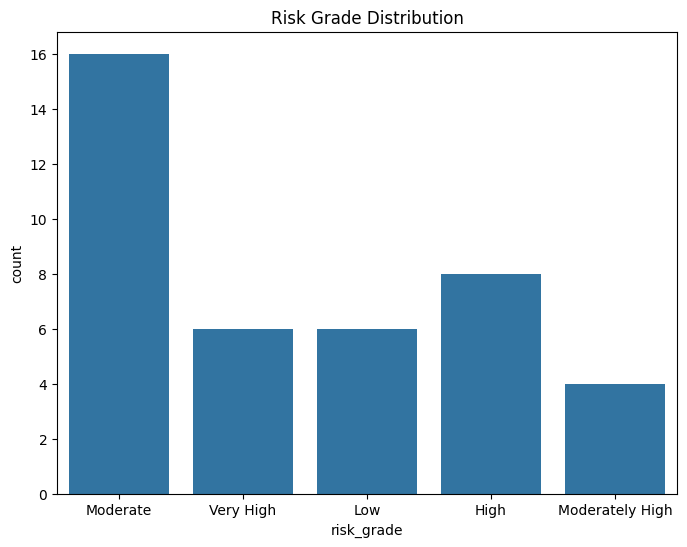

In [20]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=scheme_performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.show()

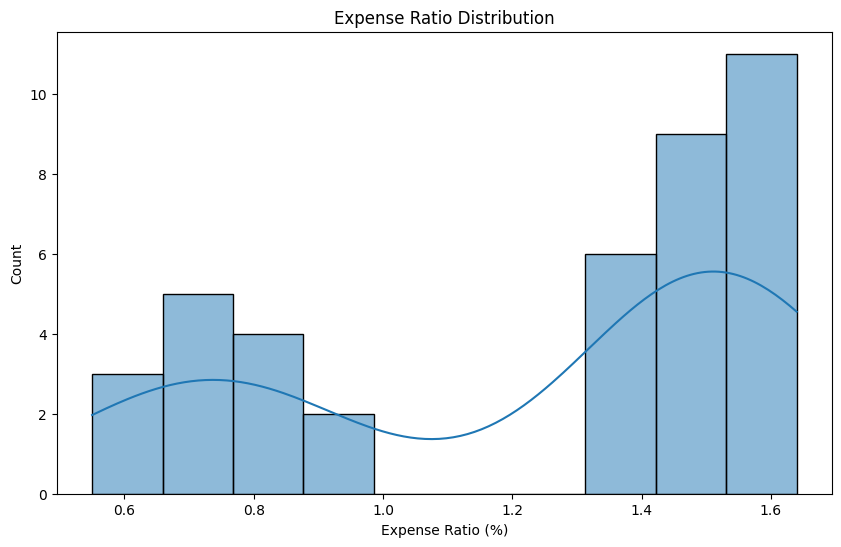

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    scheme_performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.show()

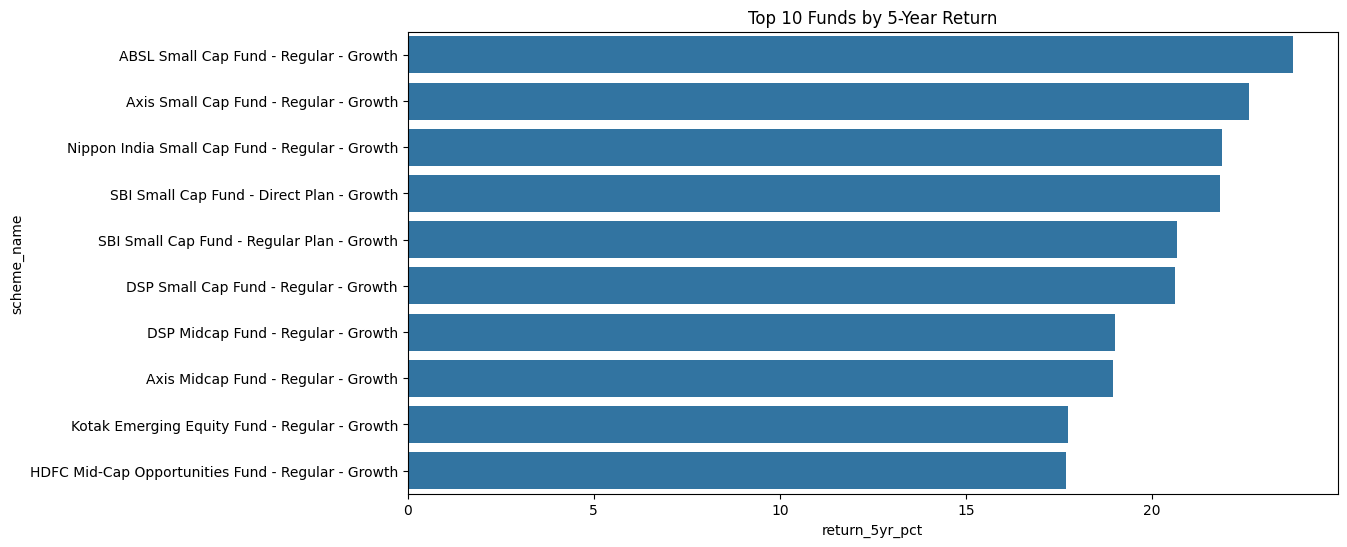

In [22]:
top_returns = scheme_performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_returns,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")

plt.show()

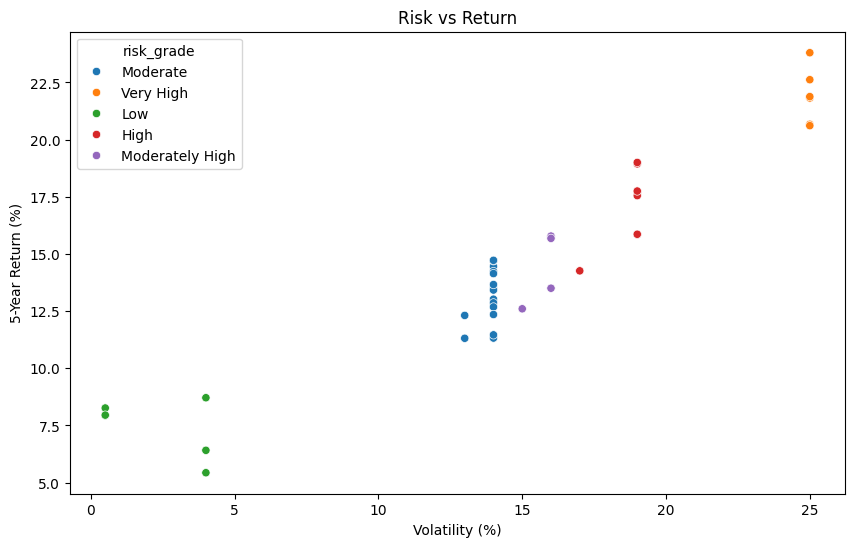

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=scheme_performance,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    hue="risk_grade"
)

plt.title("Risk vs Return")

plt.xlabel("Volatility (%)")
plt.ylabel("5-Year Return (%)")

plt.show()

In [24]:
print(portfolio_holdings.columns.tolist())
portfolio_holdings.head()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [25]:
print(portfolio_holdings.columns.tolist())

portfolio_holdings.head()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


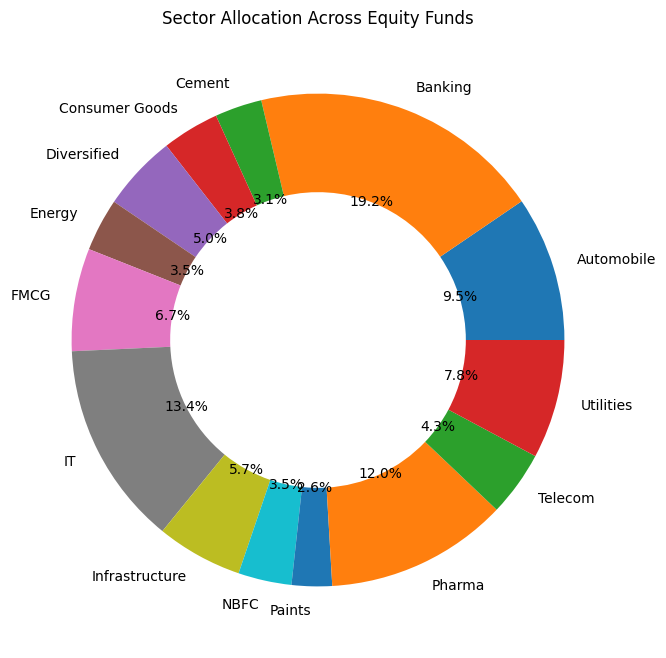

In [ ]:
sector_data = portfolio_holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

# Key EDA Findings

## 1. NAV Trends
- Most mutual funds showed steady NAV growth between 2022 and 2025.
- Several funds experienced strong upward momentum during 2024–2025.

## 2. AUM Growth
- SBI Mutual Fund maintained the highest AUM among major fund houses.
- Most fund houses showed consistent AUM growth from 2022 to 2025.

## 3. SIP Inflows
- Monthly SIP inflows increased from approximately ₹11,500 Cr in 2022 to over ₹31,000 Cr in 2025.
- SIP participation has grown steadily over the analysis period.

## 4. Category Inflows
- Liquid Funds received the highest inflows across most months.
- Mid Cap, Small Cap, and Flexi Cap categories attracted strong investor interest.

## 5. Investor Demographics
- The 26–35 age group represented the largest investor segment.
- Investment participation was distributed across multiple age groups.

## 6. Geographic Distribution
- Investments were concentrated in a limited number of major states and cities.
- Urban centers contributed a significant share of total investments.

## 7. Risk and Return
- Higher-risk funds generally delivered higher long-term returns.
- Expense ratios remained within acceptable industry ranges.